<a href="https://colab.research.google.com/github/bellajelly/K-Means-and-DBSAN/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [5]:
from google.colab import files
uploaded = files.upload()

Saving moral.data to moral.data


In [6]:
with open('moral.data', 'r') as f:
    lines = f.readlines()

cases = {}
for line in lines:
    line = line.strip()
    if not line:
        continue
    m2 = re.match(r'(\w+)\((\w+),(\w+)\)\.', line)
    m1 = re.match(r'(\w+)\((\w+)\)\.', line)
    if m2:
        feature, case, value = m2.groups()
        if case not in cases: cases[case] = {}
        cases[case][feature] = value
    elif m1:
        feature, case = m1.groups()
        if case not in cases: cases[case] = {}
        cases[case][feature] = 'y'

for case in cases:
    if 'guilty' not in cases[case]:
        cases[case]['guilty'] = 'n'

df = pd.DataFrame.from_dict(cases, orient='index')
df.index.name = 'case'
df = df.reset_index()

print(df.shape)
df.head()

(202, 25)


,case,guilty,sufficient_for_harm,produce_harm,plan_known,plan_include_harm,someone_else_cause_harm,outrank_perpetrator,monitor,harm_caused_as_planned,...,benefit_protagonist,careful,benefit_victim,severity_harm,achieve_goal,intervening_contribution,foreseeability,external_force,mental_state,necessary_for_harm
0,p0,y,n,y,y,y,n,n,y,y,...,y,y,0,1,n,n,high,n,negligent,y
1,p1,y,y,n,n,n,n,y,y,y,...,y,n,0,1,n,n,high,n,negligent,n
2,p2,y,y,y,n,n,n,y,y,y,...,y,n,0,1,n,n,high,n,negligent,y
3,p3,y,y,y,y,y,n,y,y,y,...,y,n,0,1,n,n,high,n,negligent,y
4,p4,y,y,y,y,n,n,y,y,n,...,n,y,0,1,n,n,high,n,negligent,n


Thus far, the dataset looks to have 25 features, with 202 cases

In [7]:
print("=== SUMMARY STATISTICS ===")
print(df.describe(include='all'))

print("\n=== GUILTY VALUE COUNTS ===")
print(df['guilty'].value_counts())

=== SUMMARY STATISTICS ===
       case guilty sufficient_for_harm produce_harm plan_known  \
count   202    202                 202          202        202   
unique  202      2                   2            2          2   
top      p0      y                   y            y          y   
freq      1    102                 118          123        120   

       plan_include_harm someone_else_cause_harm outrank_perpetrator monitor  \
count                202                     202                 202     202   
unique                 2                       2                   2       2   
top                    y                       n                   y       y   
freq                 109                     106                 107     115   

       harm_caused_as_planned  ... benefit_protagonist careful benefit_victim  \
count                     202  ...                 202     202            202   
unique                      2  ...                   2       2              2  

Next is one hot encoding

In [8]:
df_enc = df.copy()

# Binary y/n columns → 1/0
yn_cols = ['sufficient_for_harm','produce_harm','plan_known','plan_include_harm',
           'someone_else_cause_harm','outrank_perpetrator','monitor',
           'harm_caused_as_planned','goal_outweigh_harm','goal_achieveable_less_harmful',
           'foresee_intervention','external_cause','control_perpetrator',
           'benefit_protagonist','careful','achieve_goal','intervening_contribution',
           'external_force','necessary_for_harm','guilty']

for col in yn_cols:
    df_enc[col] = (df_enc[col] == 'y').astype(int)

df_enc['benefit_victim'] = df_enc['benefit_victim'].astype(int)
df_enc['severity_harm'] = df_enc['severity_harm'].astype(int)

# foreseeability and mental_state → one-hot encoding
df_enc = pd.get_dummies(df_enc, columns=['foreseeability'], prefix='foreseeability')
df_enc = pd.get_dummies(df_enc, columns=['mental_state'], prefix='mental_state')

print(df_enc.columns.tolist())

['case', 'guilty', 'sufficient_for_harm', 'produce_harm', 'plan_known', 'plan_include_harm', 'someone_else_cause_harm', 'outrank_perpetrator', 'monitor', 'harm_caused_as_planned', 'goal_outweigh_harm', 'goal_achieveable_less_harmful', 'foresee_intervention', 'external_cause', 'control_perpetrator', 'benefit_protagonist', 'careful', 'benefit_victim', 'severity_harm', 'achieve_goal', 'intervening_contribution', 'external_force', 'necessary_for_harm', 'foreseeability_high', 'foreseeability_low', 'foreseeability_n', 'mental_state_intend', 'mental_state_negligent', 'mental_state_neither', 'mental_state_reckless']


In [9]:
# Separate labels before clustering
labels = df_enc['guilty'].values

# Features only — drop case ID and guilty label
features = df_enc.drop(columns=['case', 'guilty'])

# Scale so no feature dominates by magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Feature matrix shape:", X_scaled.shape)
print("Labels shape:", labels.shape)

Feature matrix shape: (202, 28)
Labels shape: (202,)


KeyError: 'control_penetrator'

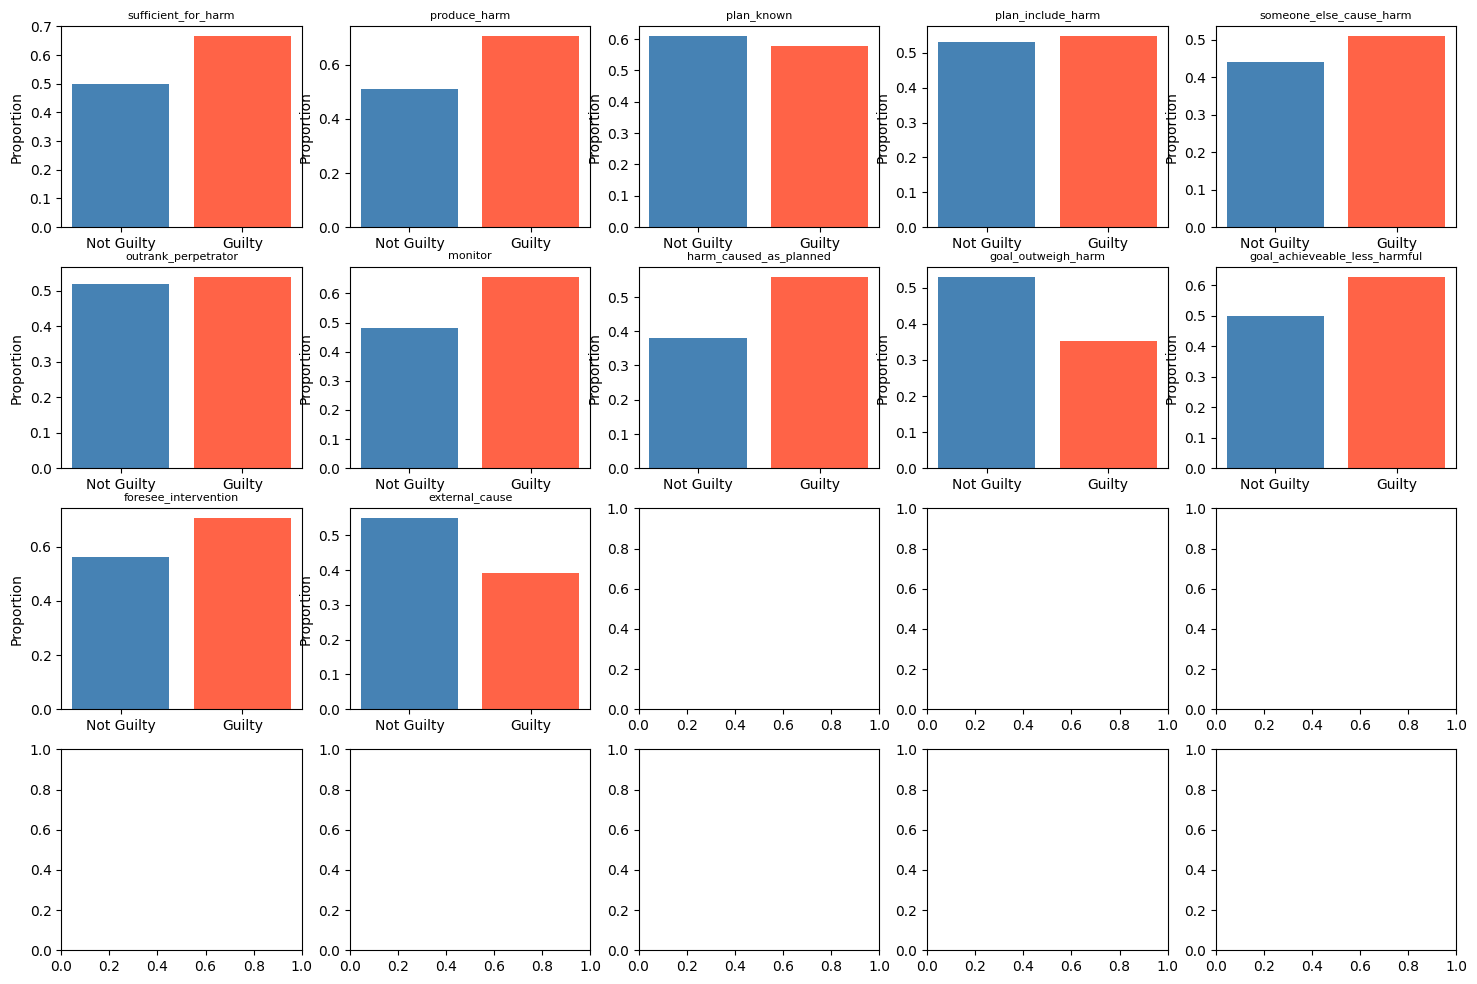

In [10]:
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

yn_display_cols = ['sufficient_for_harm','produce_harm','plan_known','plan_include_harm',
           'someone_else_cause_harm','outrank_perpetrator','monitor',
           'harm_caused_as_planned','goal_outweigh_harm','goal_achieveable_less_harmful',
           'foresee_intervention','external_cause','control_penetrator',
           'benefit_protagonist','careful','achieve_goal','intervening_contribution',
           'external_force','necessary_for_harm']

for i, col in enumerate(yn_display_cols):
    axes[i].bar(['Not Guilty', 'Guilty'],
                [df_enc[df_enc['guilty']==0][col].mean(),
                 df_enc[df_enc['guilty']==1][col].mean()],
                color=['steelblue','tomato'])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_ylabel('Proportion')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Proportions: Guilty vs Not Guilty', fontsize=13)
plt.tight_layout()
plt.show()

This is actually telling you something meaningful about moral reasoning — not just about the data. The features that matter most are about whether harm was actually produced and whether it was planned. That aligns with how humans actually think about guilt — intent and causation are central. this dataset was built by moral psychologists to model how ordinary people reason about guilt. The features weren't chosen randomly. They reflect real psychological research about what factors humans weigh when assigning blame.

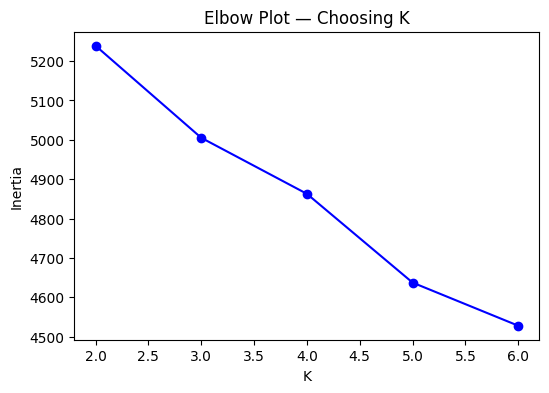

In [11]:
#Choosing K
inertias = []
ks = range(2, 7)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Plot — Choosing K')
plt.show()

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained by 2 components: 15.5%


PCA explains only 15% of variance, so visual cluster separation is limited. ARI scores are used as the primary evaluation metric

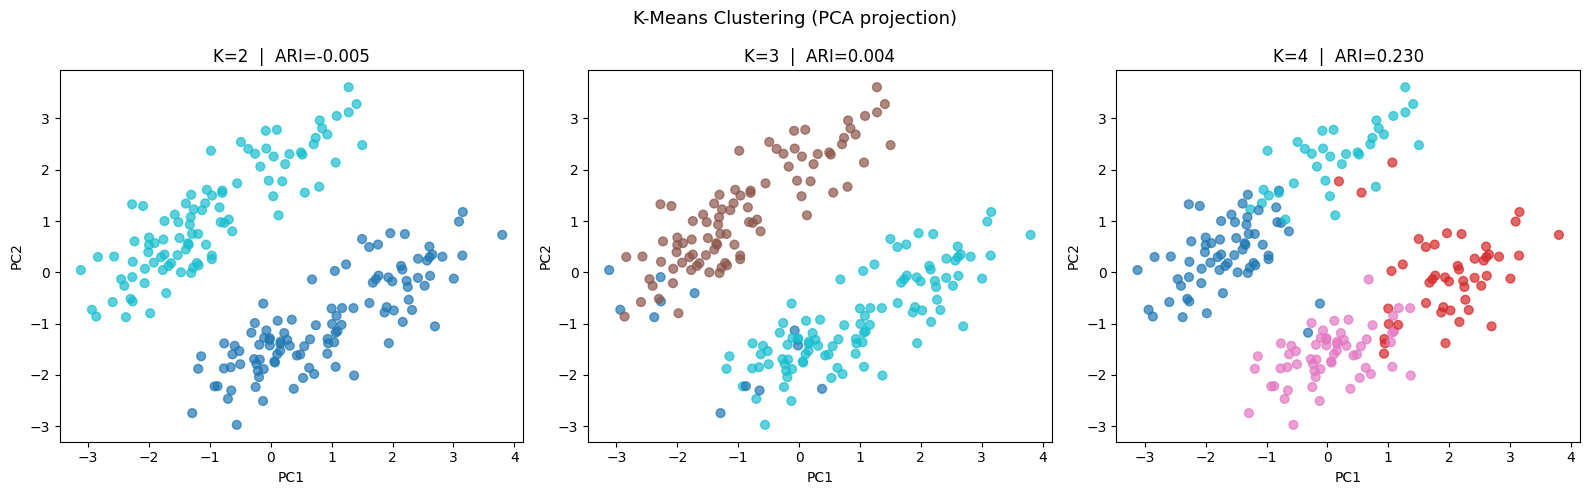

ARI scores: {2: -0.004888917928583084, 3: 0.004040601790268365, 4: 0.22964534498169067}


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ari_scores = {}

for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    ari = adjusted_rand_score(labels, cluster_labels)
    ari_scores[k] = ari

    ax.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels,
               cmap='tab10', alpha=0.7, s=40)
    ax.set_title(f'K={k}  |  ARI={ari:.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('K-Means Clustering (PCA projection)', fontsize=13)
plt.tight_layout()
plt.show()

print("ARI scores:", ari_scores)

K=2, ARI ≈ 0 — the clusters are essentially random relative to guilty/not guilty. No better than chance.
K=3, ARI ≈ 0 — still basically random.
K=4, ARI = 0.23 — meaningfully better, but still not strong. A perfect score would be 1.0.

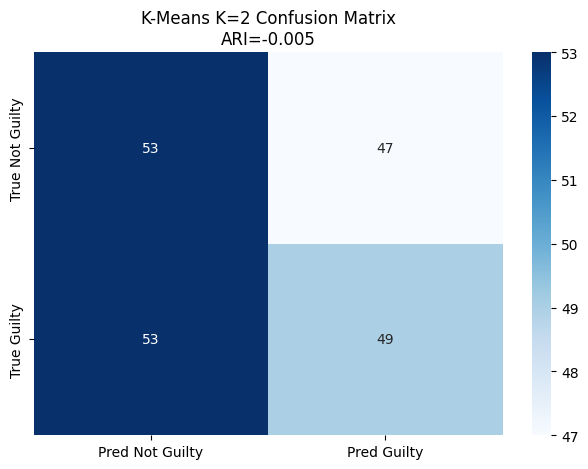

Object `code` not found.


In [14]:
#Confusion Matrix
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km2_labels = km2.fit_predict(X_scaled)

# Map clusters to labels by majority vote
cluster_to_label = {}
for c in [0, 1]:
    mask = km2_labels == c
    cluster_to_label[c] = int(labels[mask].mean() > 0.5)

mapped = np.array([cluster_to_label[c] for c in km2_labels])
cm = confusion_matrix(labels, mapped)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Not Guilty','Pred Guilty'],
            yticklabels=['True Not Guilty','True Guilty'])
plt.title(f'K-Means K=2 Confusion Matrix\nARI={ari_scores[2]:.3f}')
plt.tight_layout()
plt.show()
Run that — and look at the majority vote mapping step. That's exactly the manual mapping step we talked about earlier. Does it make more sense now seeing it in code?

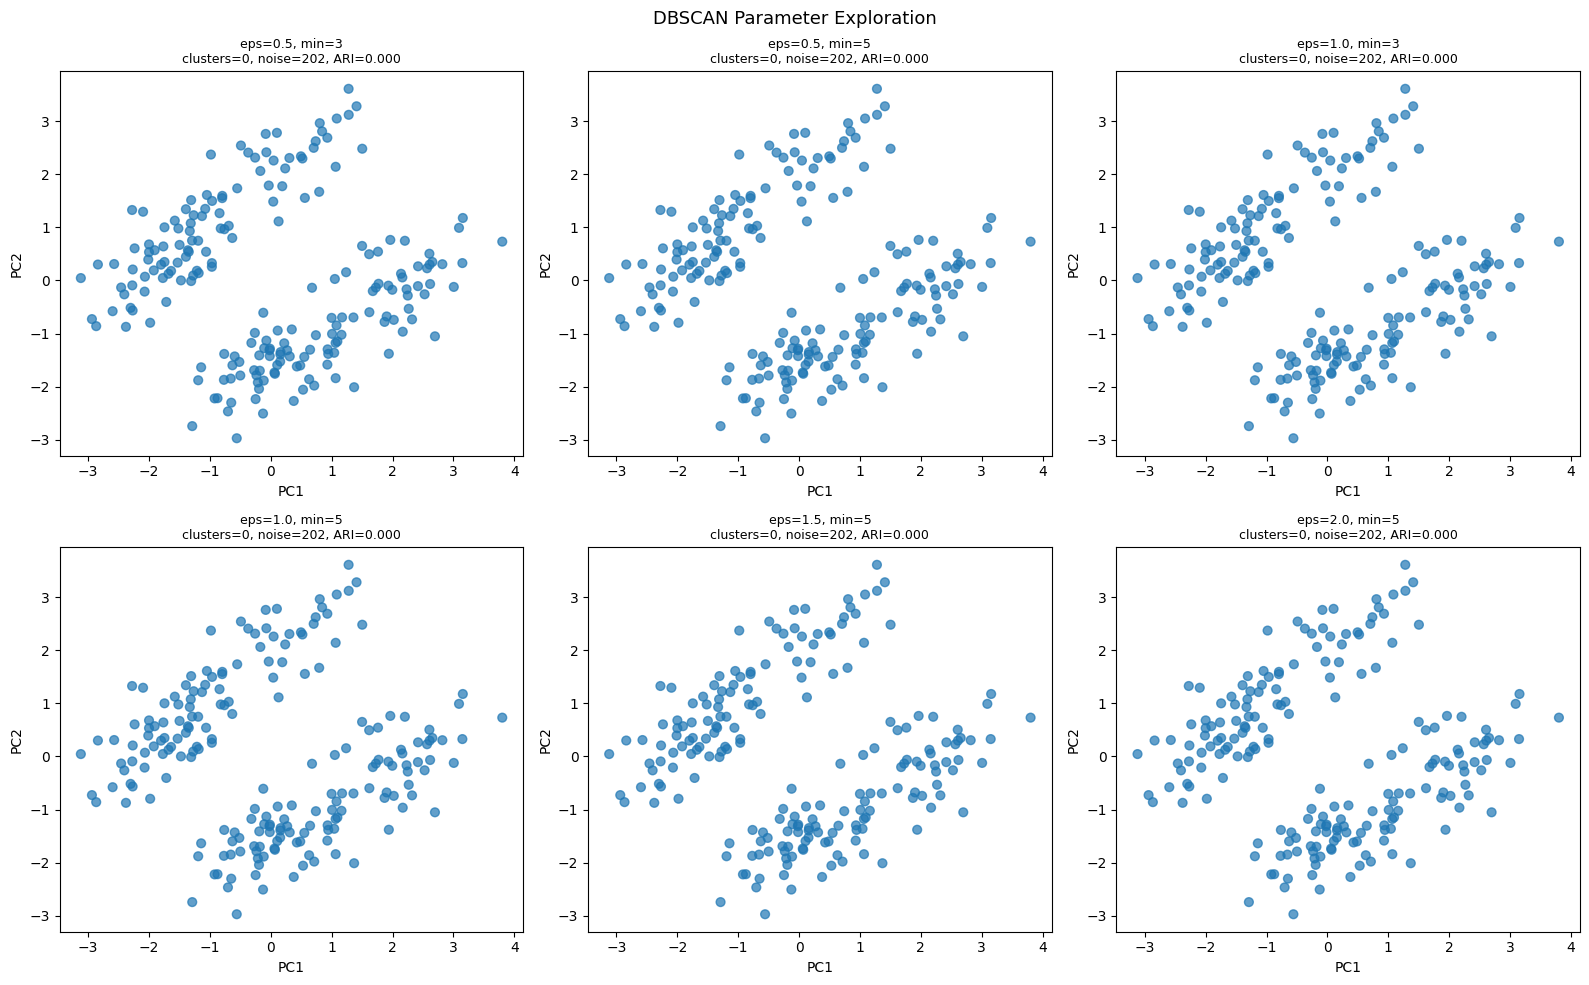

In [15]:
# Run DBSCAN
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
params = [(0.5,3),(0.5,5),(1.0,3),(1.0,5),(1.5,5),(2.0,5)]

for ax, (eps, min_s) in zip(axes, params):
    db = DBSCAN(eps=eps, min_samples=min_s)
    db_labels = db.fit_predict(X_scaled)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    ari = adjusted_rand_score(labels, db_labels)

    ax.scatter(X_pca[:,0], X_pca[:,1], c=db_labels,
               cmap='tab10', alpha=0.7, s=40)
    ax.set_title(f'eps={eps}, min={min_s}\nclusters={n_clusters}, noise={n_noise}, ARI={ari:.3f}',
                 fontsize=9)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('DBSCAN Parameter Exploration', fontsize=13)
plt.tight_layout()
plt.show()

DBSCAN failed to identify meaningful clusters regardless of eps and min_samples values, producing zero clusters and classifying all points as noise. This suggests the moral reasoning cases are uniformly distributed in feature space with no density-based structure.

#Reflection:
Both these methods weren't very effective for the moral reasoning dataset, which is based on real results of experiments into what factors humans focus on when determining guilt. Neither test was effectively able to determine guilt vs no guilt, even with 30 different features. Unsurprisingly, moral reasing is difficult, murky and its hard to treat guilt and no guilt as an easy decision. Especially wnen lives are involved.

#Model limitations

Even with carefully chosen features designed by moral psychologists, K-Means and DBSCAN couldn't reliably capture guilt. ARI of 0.23 at best. If a person's freedom depended on that model, it would be wrong nearly 80% of the time by that measure. That's not a tool, that's a coin flip with consequences.

#The nature of the problem itself
Guilt isn't a cluster. It's a judgment that emerges from context, intent, causation, and human values. The moral.theory file was a set of logical rules written by humans encoding moral reasoning. Even that hand-crafted rule system is a simplification of how real courts, juries, and humans actually reason.
Clustering algorithms are even further removed from that complexity.